In [31]:
import matplotlib.pyplot as plt

In [32]:
import pandas as pd
import numpy as np
#matplotlib inline

plt.style.use('default')

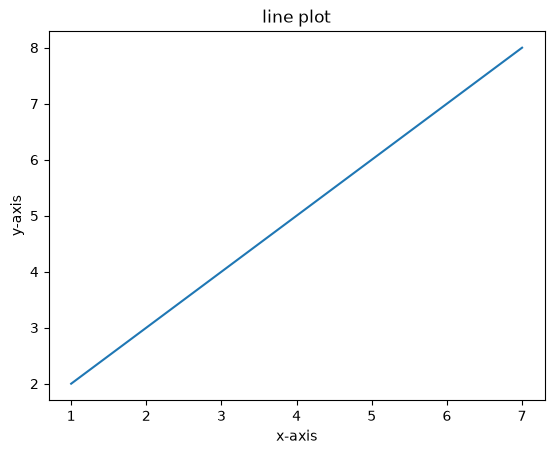

In [33]:
x = [ (1+2*i) for i in range(0,4)]
y= [(2*i+2) for i in range(0,4)]
plt.plot(x,y)
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.title("line plot")
plt.show()

Text(0.5, 1.0, 'line plot but generated better')

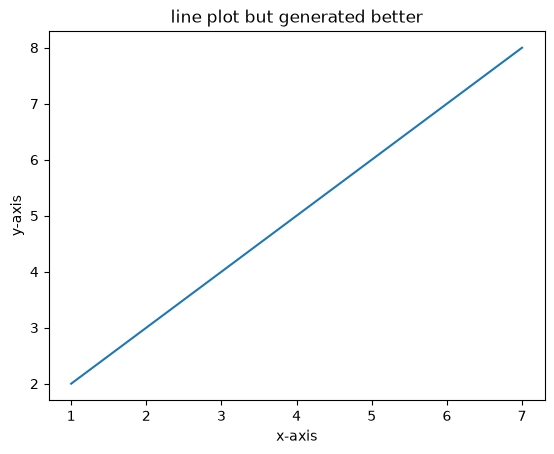

In [34]:
#using subplots (better)
#ax is short for axes, which is different than axis.
#axes are like individual graphs on the general screen (figure), axis are the data within the graphs baiscally 
fig,ax = plt.subplots() 
ax.plot(x,y)
ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")
ax.set_title('line plot but generated better')

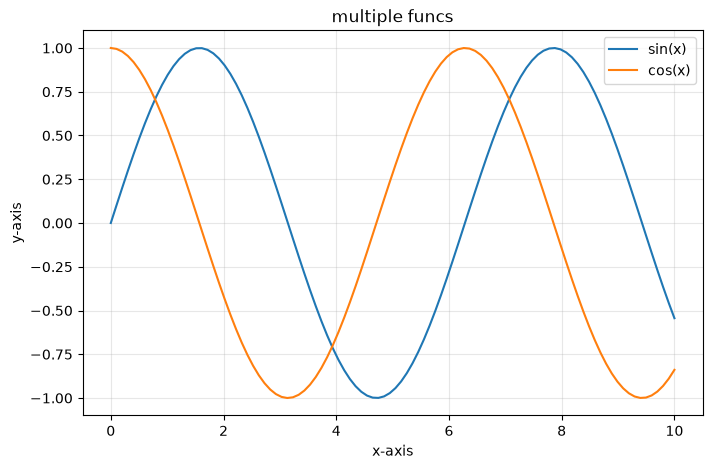

In [35]:
#basic line plot  with multiple functions
x = np.linspace(0,10,100)
y1 = np.sin(x)
y2=np.cos(x)
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(x,y1,label='sin(x)')
ax.plot(x,y2,label='cos(x)')

ax.grid(alpha=0.3)
ax.legend()

ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_title("multiple funcs")


plt.show()

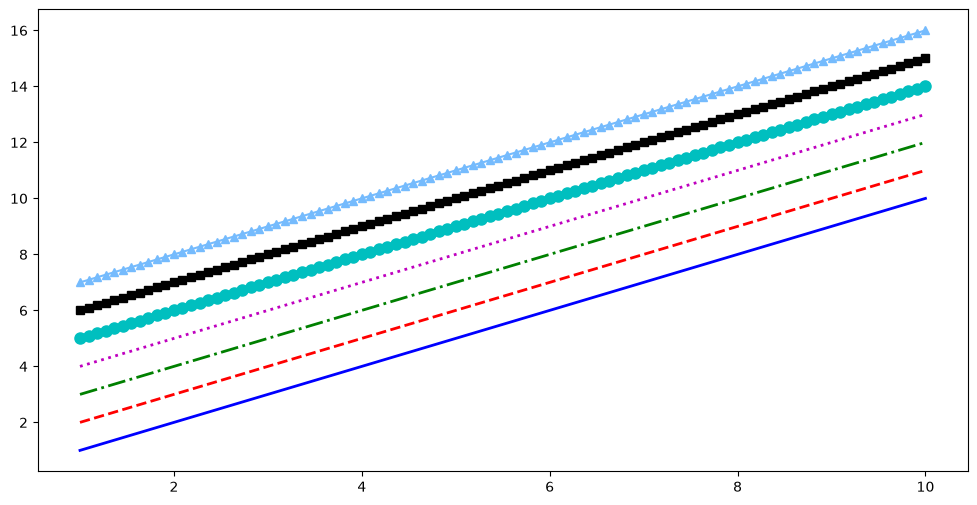

In [37]:
#customization for lines

x = np.linspace(1,10,100)

fig,ax = plt.subplots(figsize=(12,6))

ax.plot(x,x,'b-',label='solid blue line', linewidth=2)
ax.plot(x,x+1,'r--', label='dashed red line', linewidth=2)
ax.plot(x,x+2, 'g-.', label='dash-dot green line', linewidth=2)
ax.plot(x,x+3, 'm:', label='magenta dotted line', linewidth=2)
ax.plot(x,x+4, 'co-', label='cyan circles', markersize=8)
ax.plot(x,x+5, 's-', color='#000000',label='squares', markersize=6)
ax.plot(x,x+6, '^-', color='xkcd:sky blue',label='triangles', markersize=6)


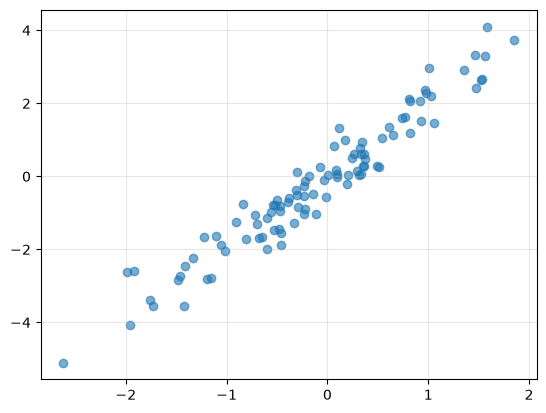

In [41]:
#scatter plots
np.random.seed(42)
x = np.random.randn(100)
y=2*x+np.random.randn(100)*0.5
plt.scatter(x,y,alpha=0.6)
plt.grid(alpha=0.3)

In [42]:
x

array([ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337,
       -0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004,
       -0.46341769, -0.46572975,  0.24196227, -1.91328024, -1.72491783,
       -0.56228753, -1.01283112,  0.31424733, -0.90802408, -1.4123037 ,
        1.46564877, -0.2257763 ,  0.0675282 , -1.42474819, -0.54438272,
        0.11092259, -1.15099358,  0.37569802, -0.60063869, -0.29169375,
       -0.60170661,  1.85227818, -0.01349722, -1.05771093,  0.82254491,
       -1.22084365,  0.2088636 , -1.95967012, -1.32818605,  0.19686124,
        0.73846658,  0.17136828, -0.11564828, -0.3011037 , -1.47852199,
       -0.71984421, -0.46063877,  1.05712223,  0.34361829, -1.76304016,
        0.32408397, -0.38508228, -0.676922  ,  0.61167629,  1.03099952,
        0.93128012, -0.83921752, -0.30921238,  0.33126343,  0.97554513,
       -0.47917424, -0.18565898, -1.10633497, -1.19620662,  0.81252582,
        1.35624003, -0.07201012,  1.0035329 ,  0.36163603, -0.64

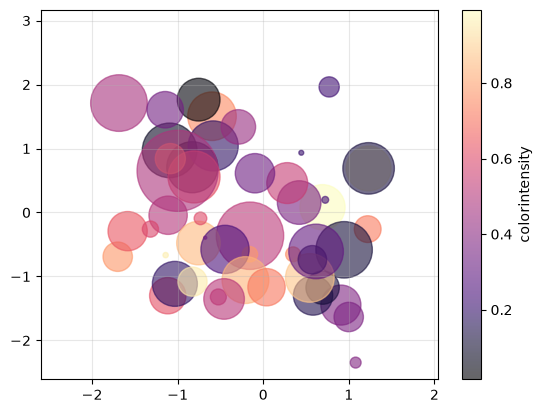

In [55]:
#scatter plots
np.random.seed(67)
x = np.random.randn(100)
y=np.random.randn(100)
colors=np.random.rand(100)
sizes=np.random.randn(100)*1000
plt.scatter(x,y,c=colors, s=sizes,alpha=0.6,cmap='magma')
plt.colorbar(label='colorintensity')
plt.grid(alpha=0.3)

In [78]:
from matplotlib.widgets import Button, Slider
%matplotlib widget

def f(t, amplitude, frequency):
    return amplitude * np.sin(2*np.pi*frequency*t)
f(np.pi/2,2,0.5/np.pi)

t = np.linspace(0,10,1000)
init_amplitude = 2
init_frequency = 3

fig,ax=plt.subplots()
line, = ax.plot(t,f(t, init_amplitude, init_frequency), lw=2)
ax.set_xlabel("time")
fig.subplots_adjust(left=0.25,bottom=0.25)
axfreq = fig.add_axes((0.25,0.1,0.68,0.03))
freq_slider=Slider(
    ax=axfreq,
    label='frequency',
    valmin=0.1,
    valmax=30,
    valinit=init_frequency
)
axamp = fig.add_axes((0.1,0.25,0.03,0.68))
amp_slider=Slider(
    ax=axamp,
    label='amplitude',
    valmin=0.0,
    valmax=10,
    valinit=init_amplitude,
    orientation='vertical'
)
def update(val):
    line.set_ydata(f(t,amp_slider.val))
    fig.canvas.draw_idle()

freq_slider.on_changed(update)
amp_slider.on_changed(update)

axreset = fig.add_axes((0.8,0.025,0.1,0.04))
button = Button(
    ax=axreset, 
    label='Reset', 
    hovercolor='0.975')

def reset(event):
    freq_slider.reset()
    amp_slider.reset()
button.on_clicked(reset)

plt.show()

RuntimeError: 'widget' is not a recognised GUI loop or backend name